# 1. Introduction to the Dataset And The Aim of the EDA

With the rapid growth of ride-hailing and taxi services, accurately estimating trip duration has become an essential task for improving customer experience and operational efficiency. Reliable travel time predictions help passengers plan their journeys, enable drivers to optimize routes, and allow fleet operators to allocate resources more effectively.

This project analyzes the NYC Taxi Trip Duration dataset, which contains detailed information about taxi trips in New York City including:

* id
* vendor_id
* pickup_datetime
* passenger_count
* pickup_longitude
* pickup_latitude
* dropoff_longitude
* dropoff_latitude
* store_and_fwd_flag
* trip_duration

Through exploratory data analysis, feature engineering, and machine learning, the goal is to understand the factors that influence trip duration and build a predictive model capable of estimating travel time as accurately as possible.

## 1.1 Library Setup and Read in the Data

In [23]:
# Scientific libraries
import numpy as np
import pandas as pd

# Visual libraries
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import missingno as msno  # Visualize missing values

# Visual setup
import matplotlib.ticker as ticker
plt.style.use('ggplot')
rcParams['axes.spines.right'] = False
rcParams['axes.spines.top'] = False
rcParams['figure.figsize'] = [12, 9]
rcParams['font.size'] = 16
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
custom_colors = ['#74a09e','#86c1b2','#98e2c6','#f3c969','#f2a553', '#d96548', '#c14953']
sns.set_palette(custom_colors)
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

# Pandas options
pd.set_option('max_colwidth', 40)
pd.options.display.max_columns = None  # Possible to limit
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

Load in the data

In [18]:
df = pd.read_csv("data/train.csv")
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


# 2. Basic Exploration and Data Cleaning

## 2.1 Basic Exploration

We will start with basic exploration of the dataset and get a feel for how it looks.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  object 
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  object 
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 76.3+ MB


There are 10 columns and maybe have missing values.
There is a column that has incorrect data types: pickup_datetime

In [6]:
df.isnull().sum()

id                    0
vendor_id             0
pickup_datetime       0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64

Hopefully the data has no missing values :D

Now, let's explore the numerical features of the dataset and see if they contain any issues:

In [7]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,1.534793,1.665353,-73.973475,40.750947,-73.973421,40.751829,9.548850e+02
std,0.498788,1.315723,0.065404,0.033745,0.065432,0.035782,3.882070e+03
min,1.000000,0.000000,-121.933342,34.359695,-121.933304,34.359695,1.000000e+00
25%,1.000000,1.000000,-73.991852,40.737372,-73.991341,40.735928,3.970000e+02
50%,2.000000,1.000000,-73.981728,40.754131,-73.979767,40.754551,6.620000e+02
75%,2.000000,2.000000,-73.967346,40.768379,-73.963036,40.769833,1.074000e+03
max,2.000000,7.000000,-61.335529,51.881084,-61.335529,43.921028,2.227612e+06


Looks like all numerical columns are within the sensible range, like passenger_count should be between 0 and 7. But the maximum value for trip_duration is 2.227612e+06 which is 25 days which is a bit suspicious. We will dig into that later.

Before we further explore, let's deal with the issues we highlighted. Here is the final list:

Issues List For the Dataset: 
* Drop these columns: id.
* Incorrect data types for pickup_datetime
* Suspicious values in trip_duration column.


## 2.2 Data Cleaning

Drop unnecessary columns.for now, just id. XD

In [8]:
df.drop(columns=['id'], axis='columns', inplace=True)

Convert *pickup_datetime* to datetime

In [21]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df.pickup_datetime.dtype

dtype('<M8[ns]')

In [20]:
df.head(1)

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040


# 3. Univariate Exploration

Time to create some plots, let's look at how categories are distributed

Let's start with vendors: vendor_id

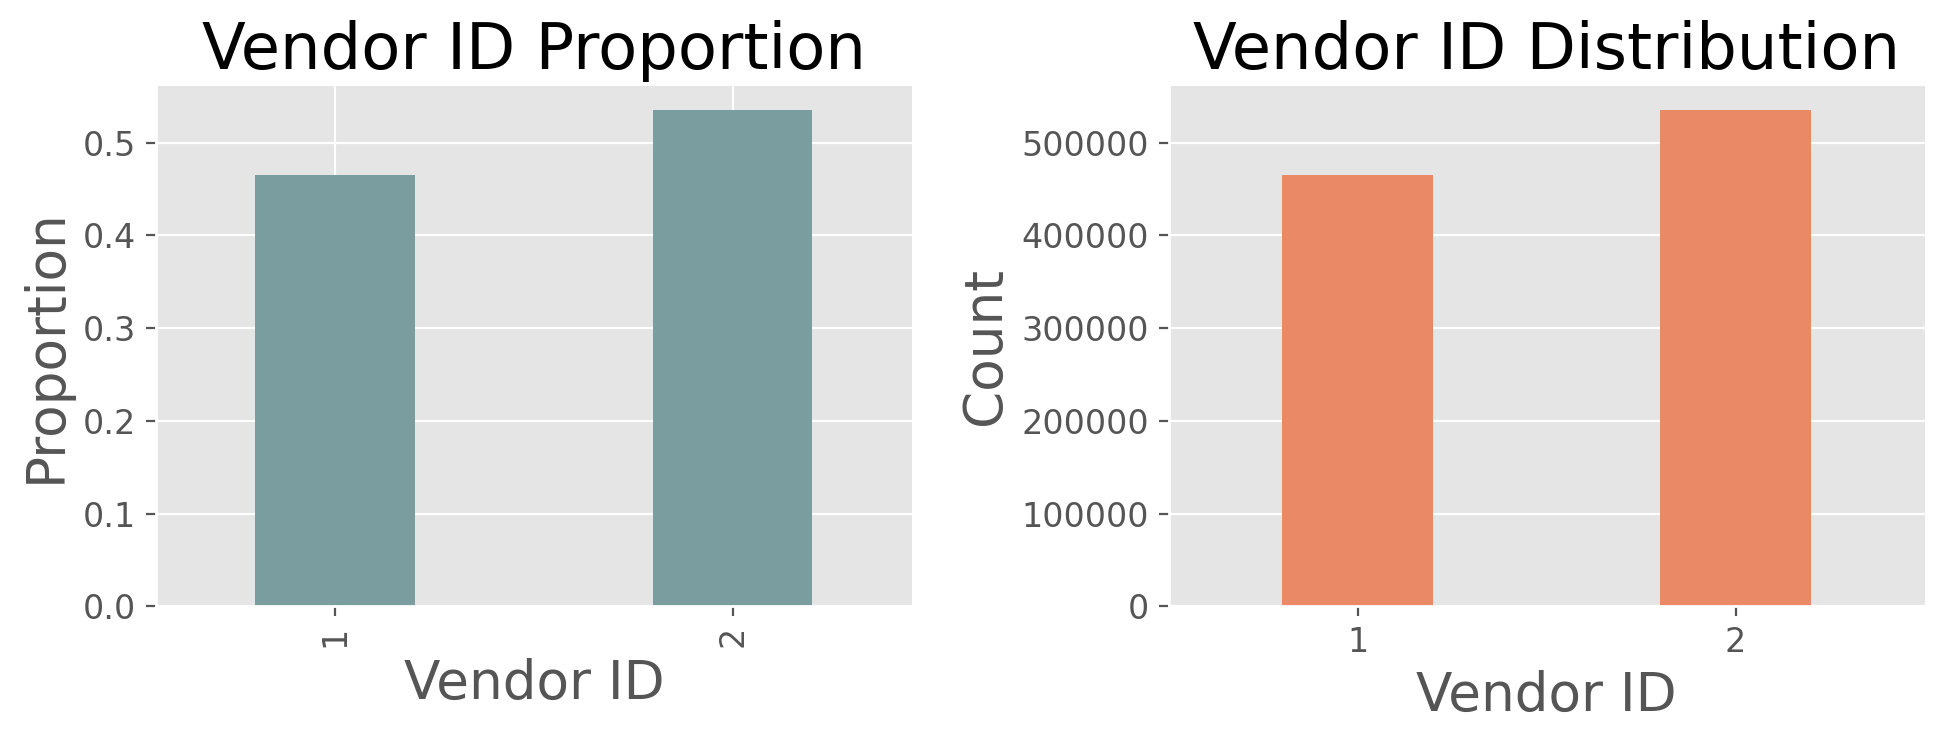

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Left: Proportion
_=df['vendor_id'].value_counts(normalize=True).sort_index().plot.bar(
    ax=ax[0],
    color='#7A9E9F',
    width=0.4
)

_=ax[0].set(
    title='Vendor ID Proportion',
    xlabel='Vendor ID',
    ylabel='Proportion'
)

# Right: Count
_=sns.countplot(
    data=df,
    x='vendor_id',
    ax=ax[1],
    color='coral',
    width=0.4
)

_=ax[1].set(
    title='Vendor ID Distribution',
    xlabel='Vendor ID',
    ylabel='Count'
)

plt.tight_layout()
plt.show()

looks like most trips were done by vendor_id=2

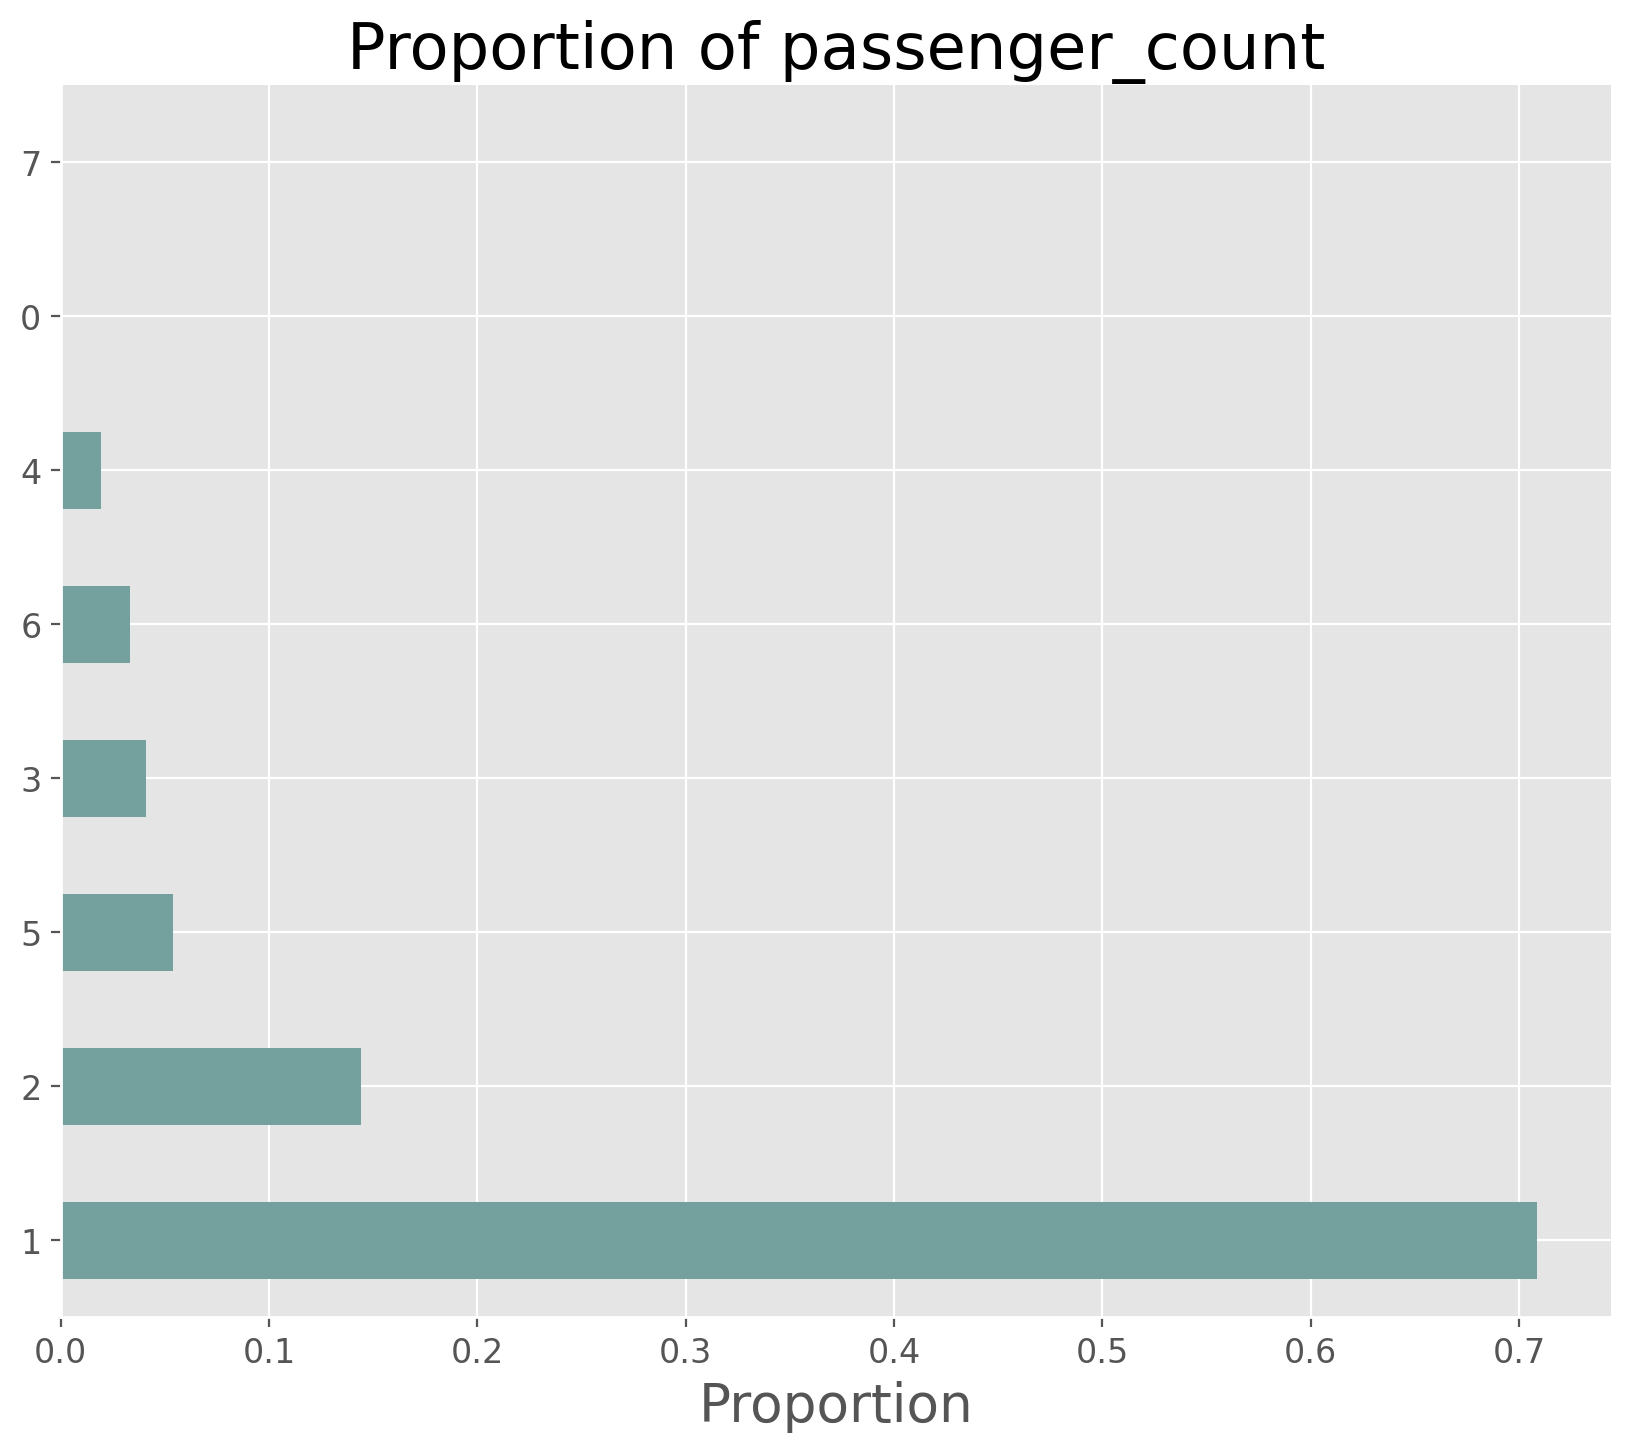

In [80]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create a normalized countplot
df.passenger_count.value_counts(normalize=True).plot.barh()

_=ax.set(title='Proportion of passenger_count',
       xlabel='Proportion', ylabel='')

plt.show();

**Findings:**
* looks like passenger_count of 0 or 7 are rare, to be removed as outliers or treated as rare values.
* passenger_count=1 has the heighst proportion, most trips were done with only one passenger.

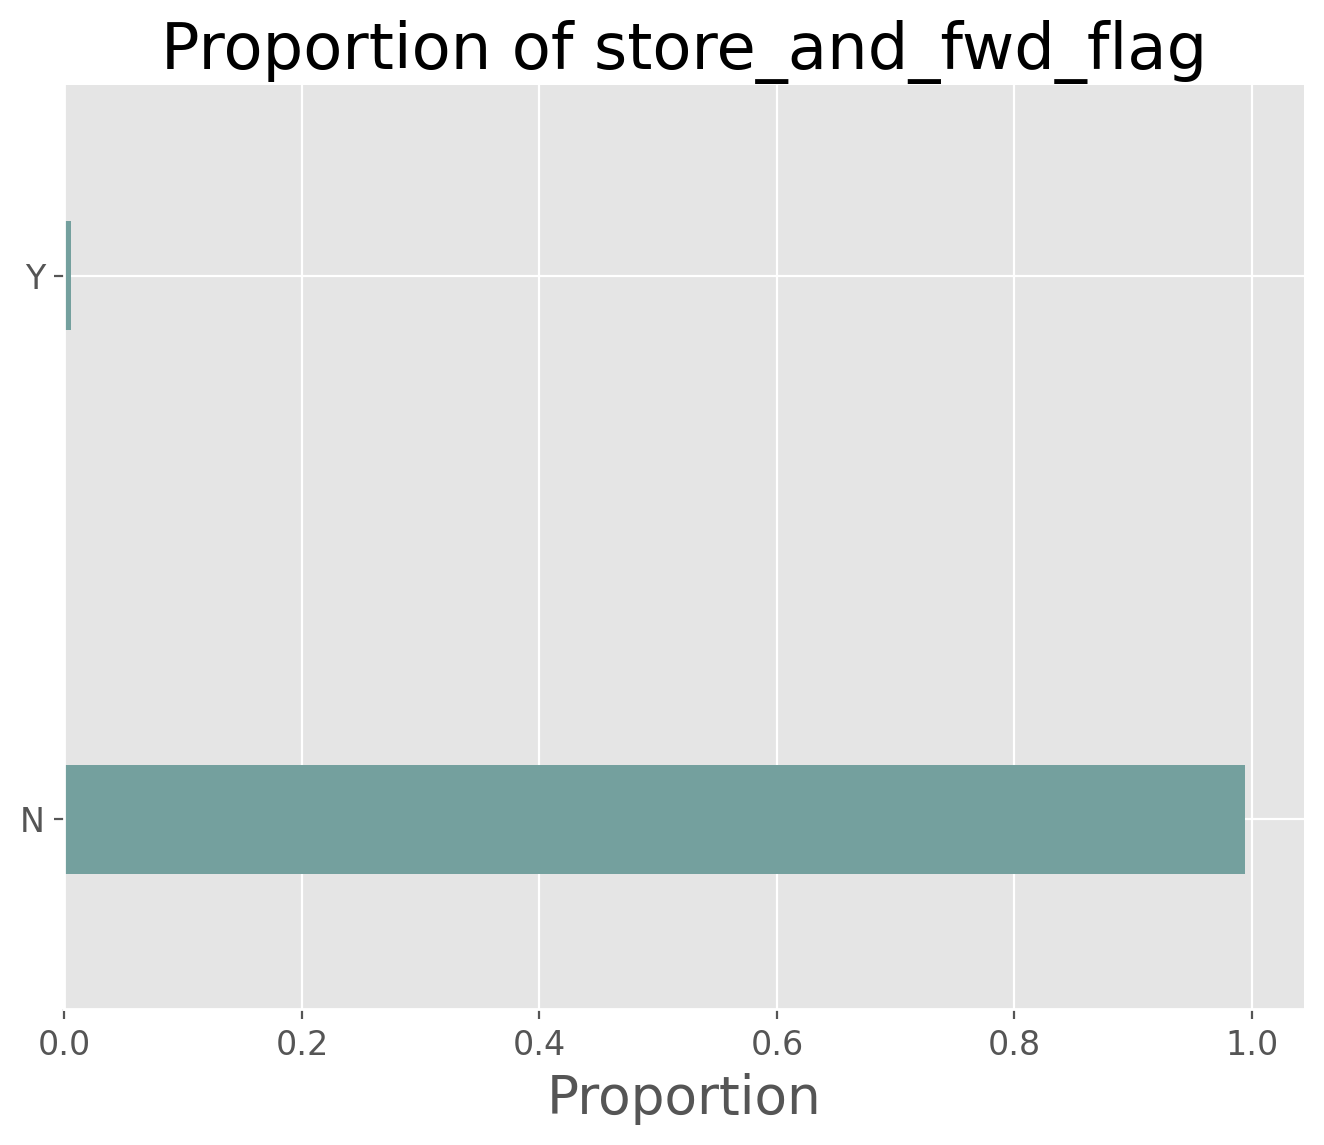

In [79]:
fig, ax = plt.subplots(figsize=(8, 6))

_=df['store_and_fwd_flag'].value_counts(normalize=True).plot.barh(
    ax=ax,
    width=0.2           # Controls bar thickness
)
_=ax.set(
    title='Proportion of store_and_fwd_flag',
    xlabel='Proportion',
    ylabel=''
)
plt.show()

most trip records were transmitted to the server in real time.

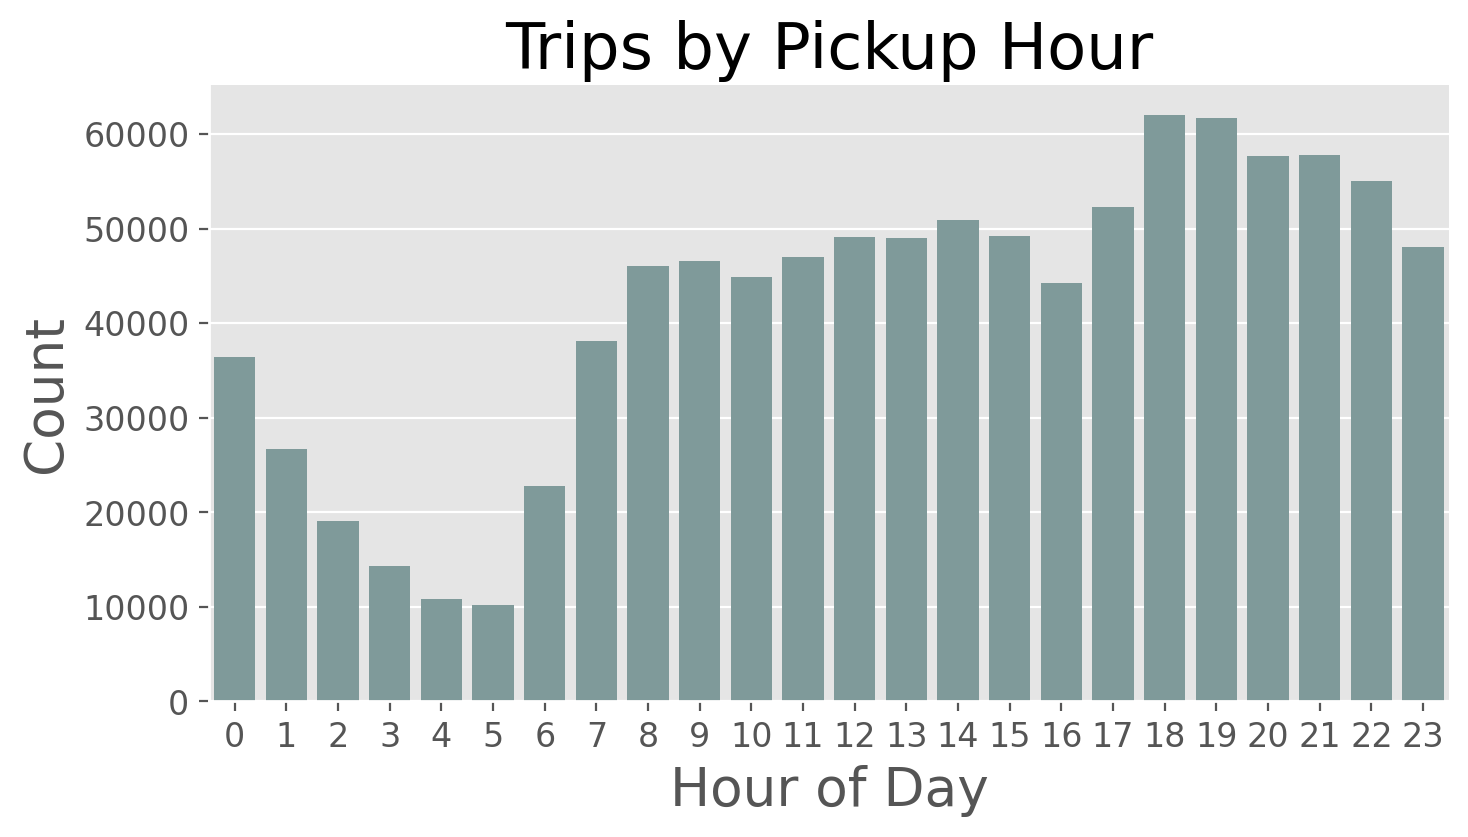

In [77]:
fig, ax = plt.subplots(figsize=(8, 4))

_=sns.countplot(
    x=df['pickup_datetime'].dt.hour,
    color='#7A9E9F',
    ax=ax
)

_=ax.set(
    title='Trips by Pickup Hour',
    xlabel='Hour of Day',
    ylabel='Count'
)

plt.show()

* The figure shows there are range of hourse per day those have the most trips **[18-22]**.
* Those have the least number of trips done range **[1-7]**.

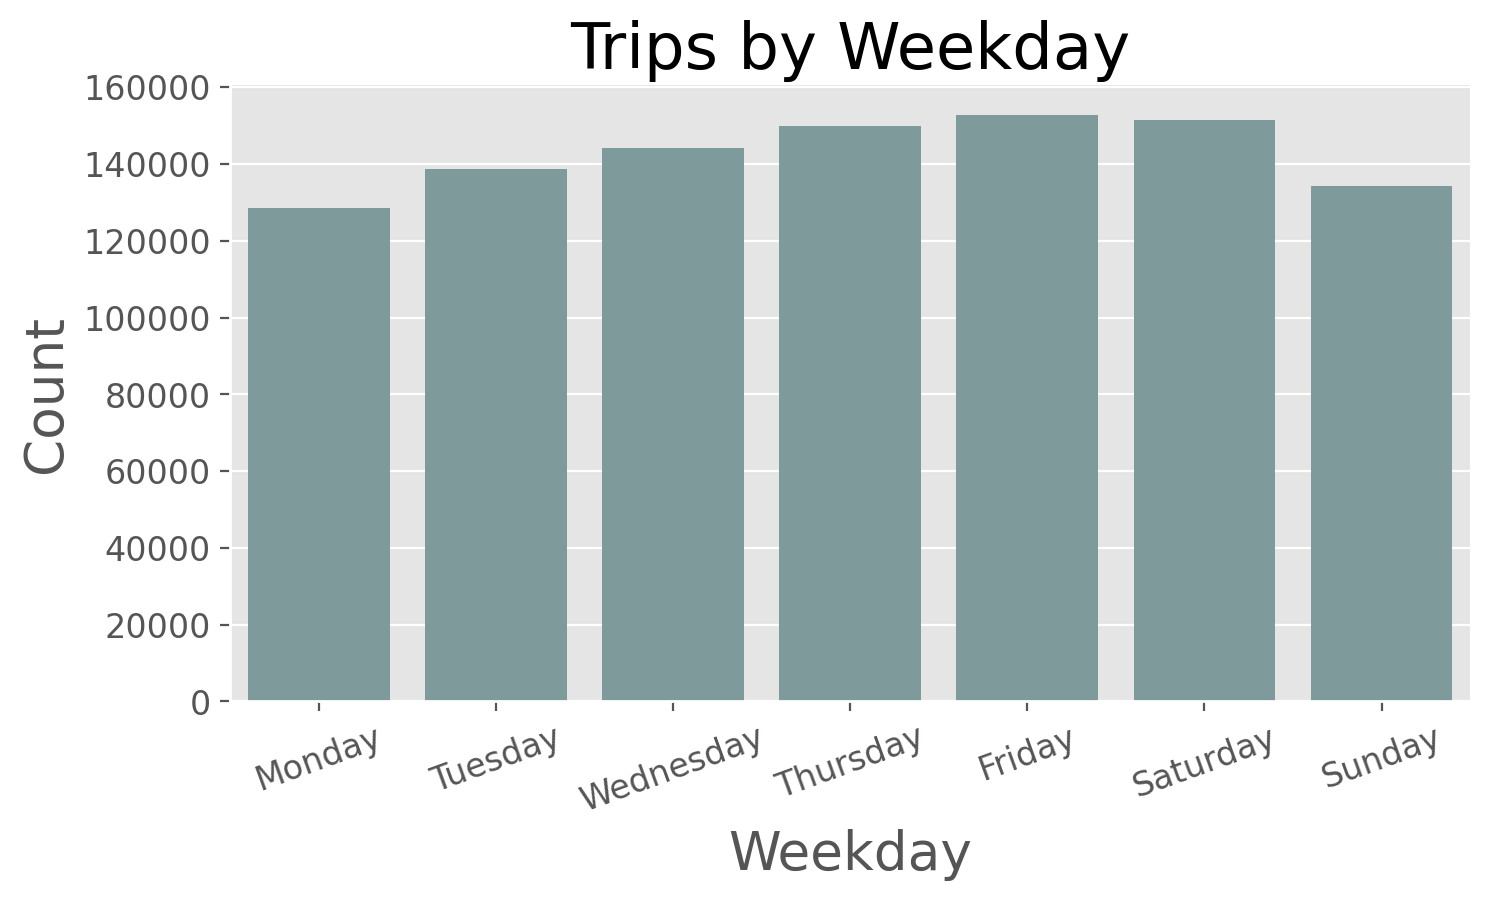

In [76]:
fig, ax = plt.subplots(figsize=(8, 4))

_=sns.countplot(
    x=df['pickup_datetime'].dt.day_name(),
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday',
           'Friday', 'Saturday', 'Sunday'],
    color='#7A9E9F',
    ax=ax
)

_=ax.set(
    title='Trips by Weekday',
    xlabel='Weekday',
    ylabel='Count'
)

_=plt.xticks(rotation=20)
plt.show()

Thursday, Friday and Saturday have the most trips of the data.

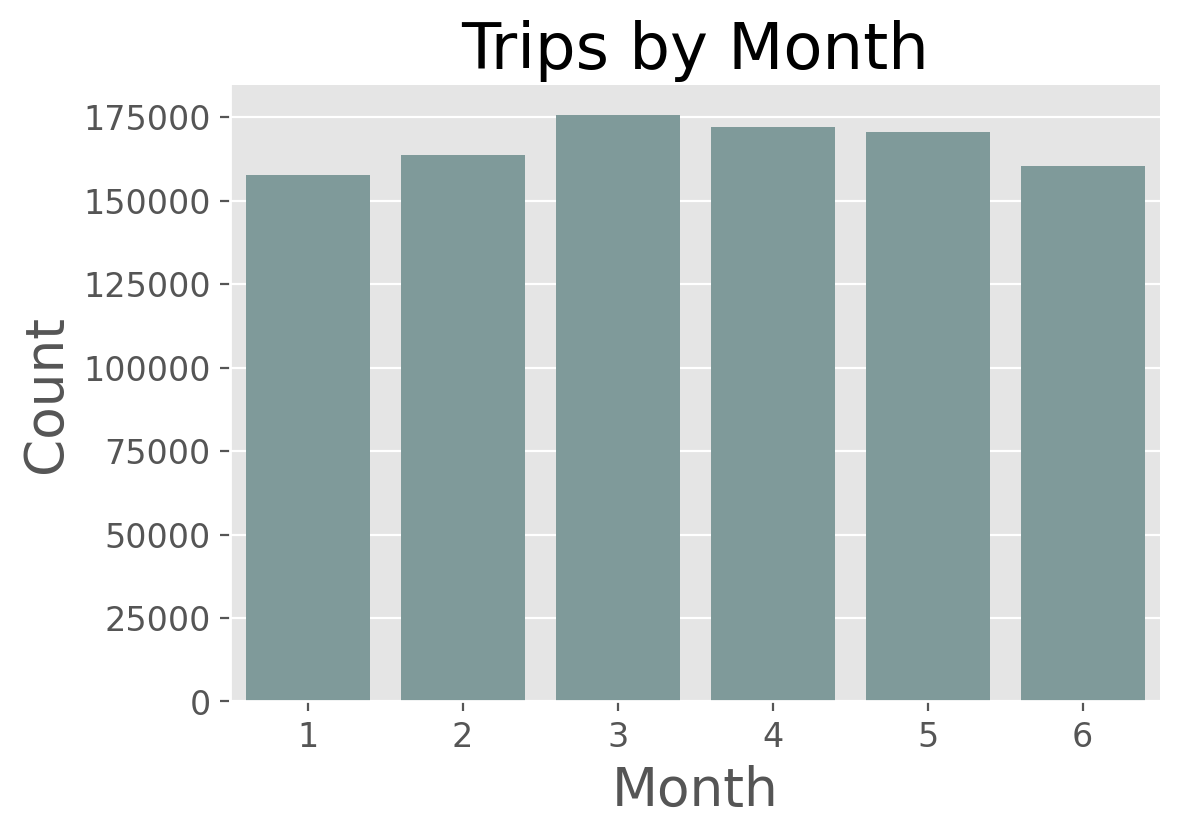

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))

_=sns.countplot(
    x=df['pickup_datetime'].dt.month,
    color='#7A9E9F',
    ax=ax
)

_=ax.set(
    title='Trips by Month',
    xlabel='Month',
    ylabel='Count'
)

plt.show()

* March has the most trips.
* As we see the data leaks of diversty of months, only contains months from 1 to 6.

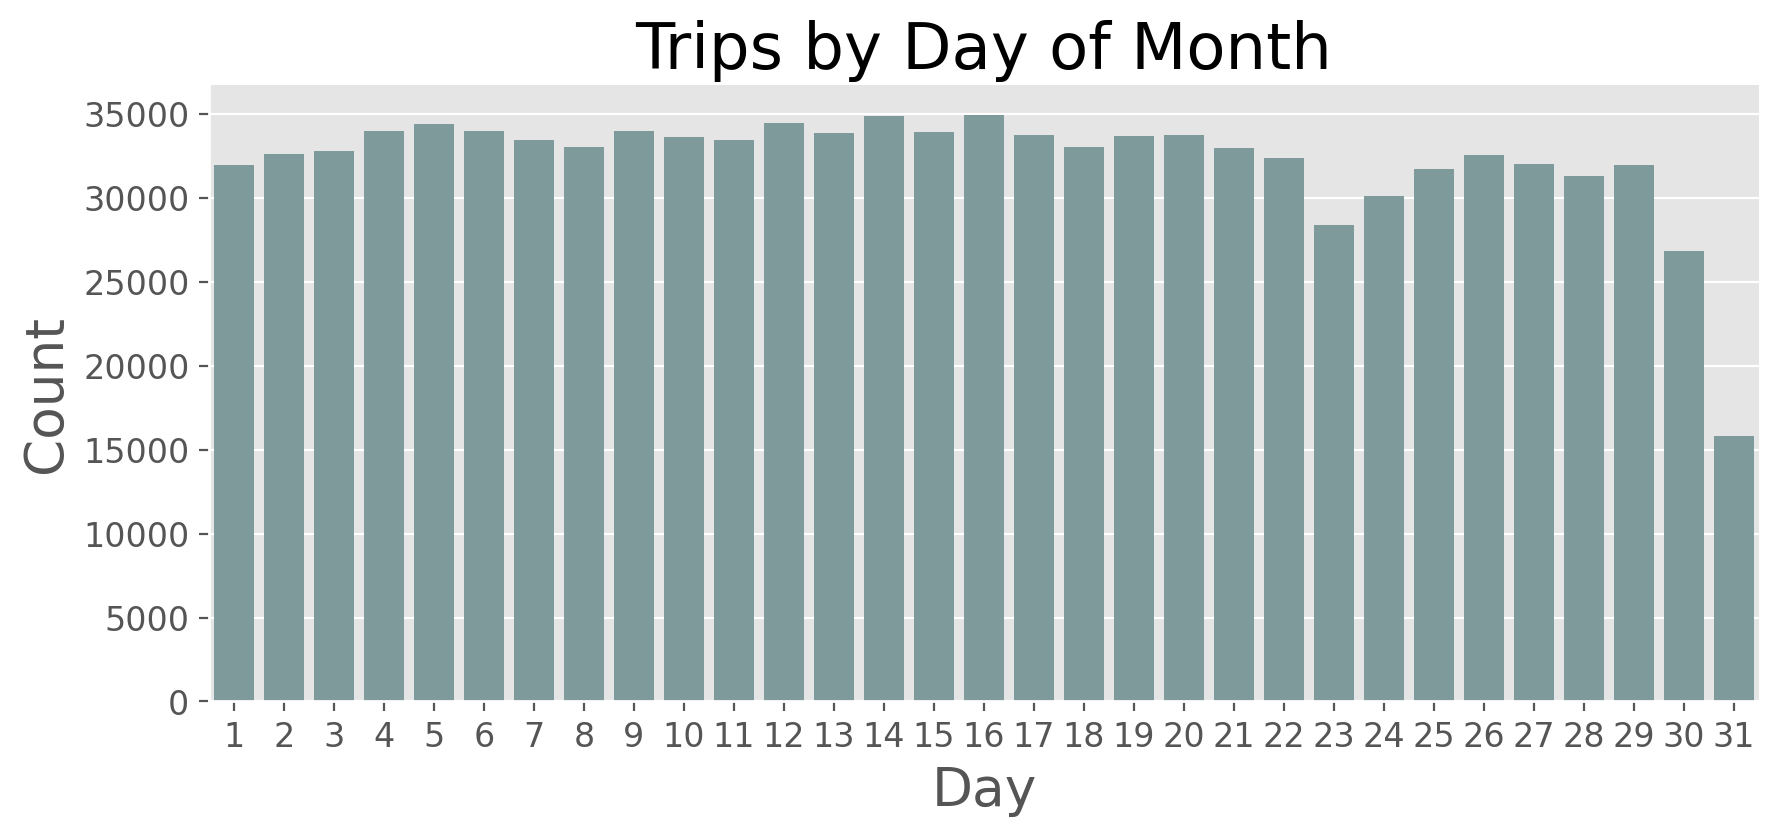

In [72]:
fig, ax = plt.subplots(figsize=(10, 4))

_=sns.countplot(
    x=df['pickup_datetime'].dt.day,
    color='#7A9E9F',
    ax=ax
)

_=ax.set(
    title='Trips by Day of Month',
    xlabel='Day',
    ylabel='Count'
)

plt.show()

* Days of each month in ranges **[12-16]** and **[4-7]** sounds have the peek of trips count.
* Least trips were done in the 31th day of each month.

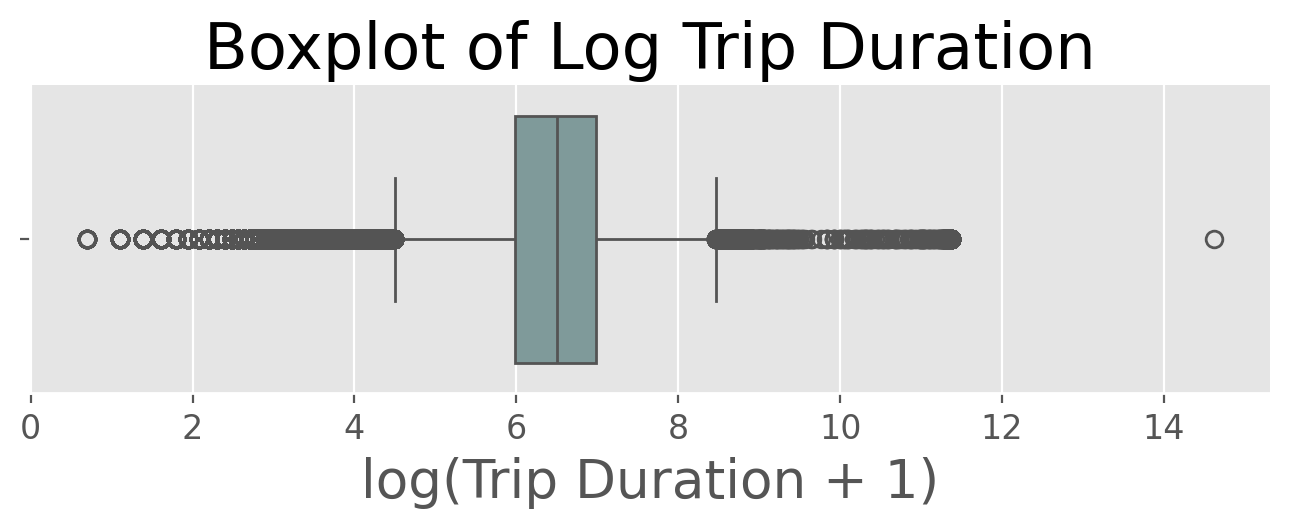

In [71]:
fig, ax = plt.subplots(figsize=(8, 2))

_=sns.boxplot(
    x=np.log1p(df['trip_duration']),
    color='#7A9E9F',
    ax=ax
)

_=ax.set(
    title='Boxplot of Log Trip Duration',
    xlabel='log(Trip Duration + 1)'
)

plt.show()

Trip duration has outliers needs to be removed.

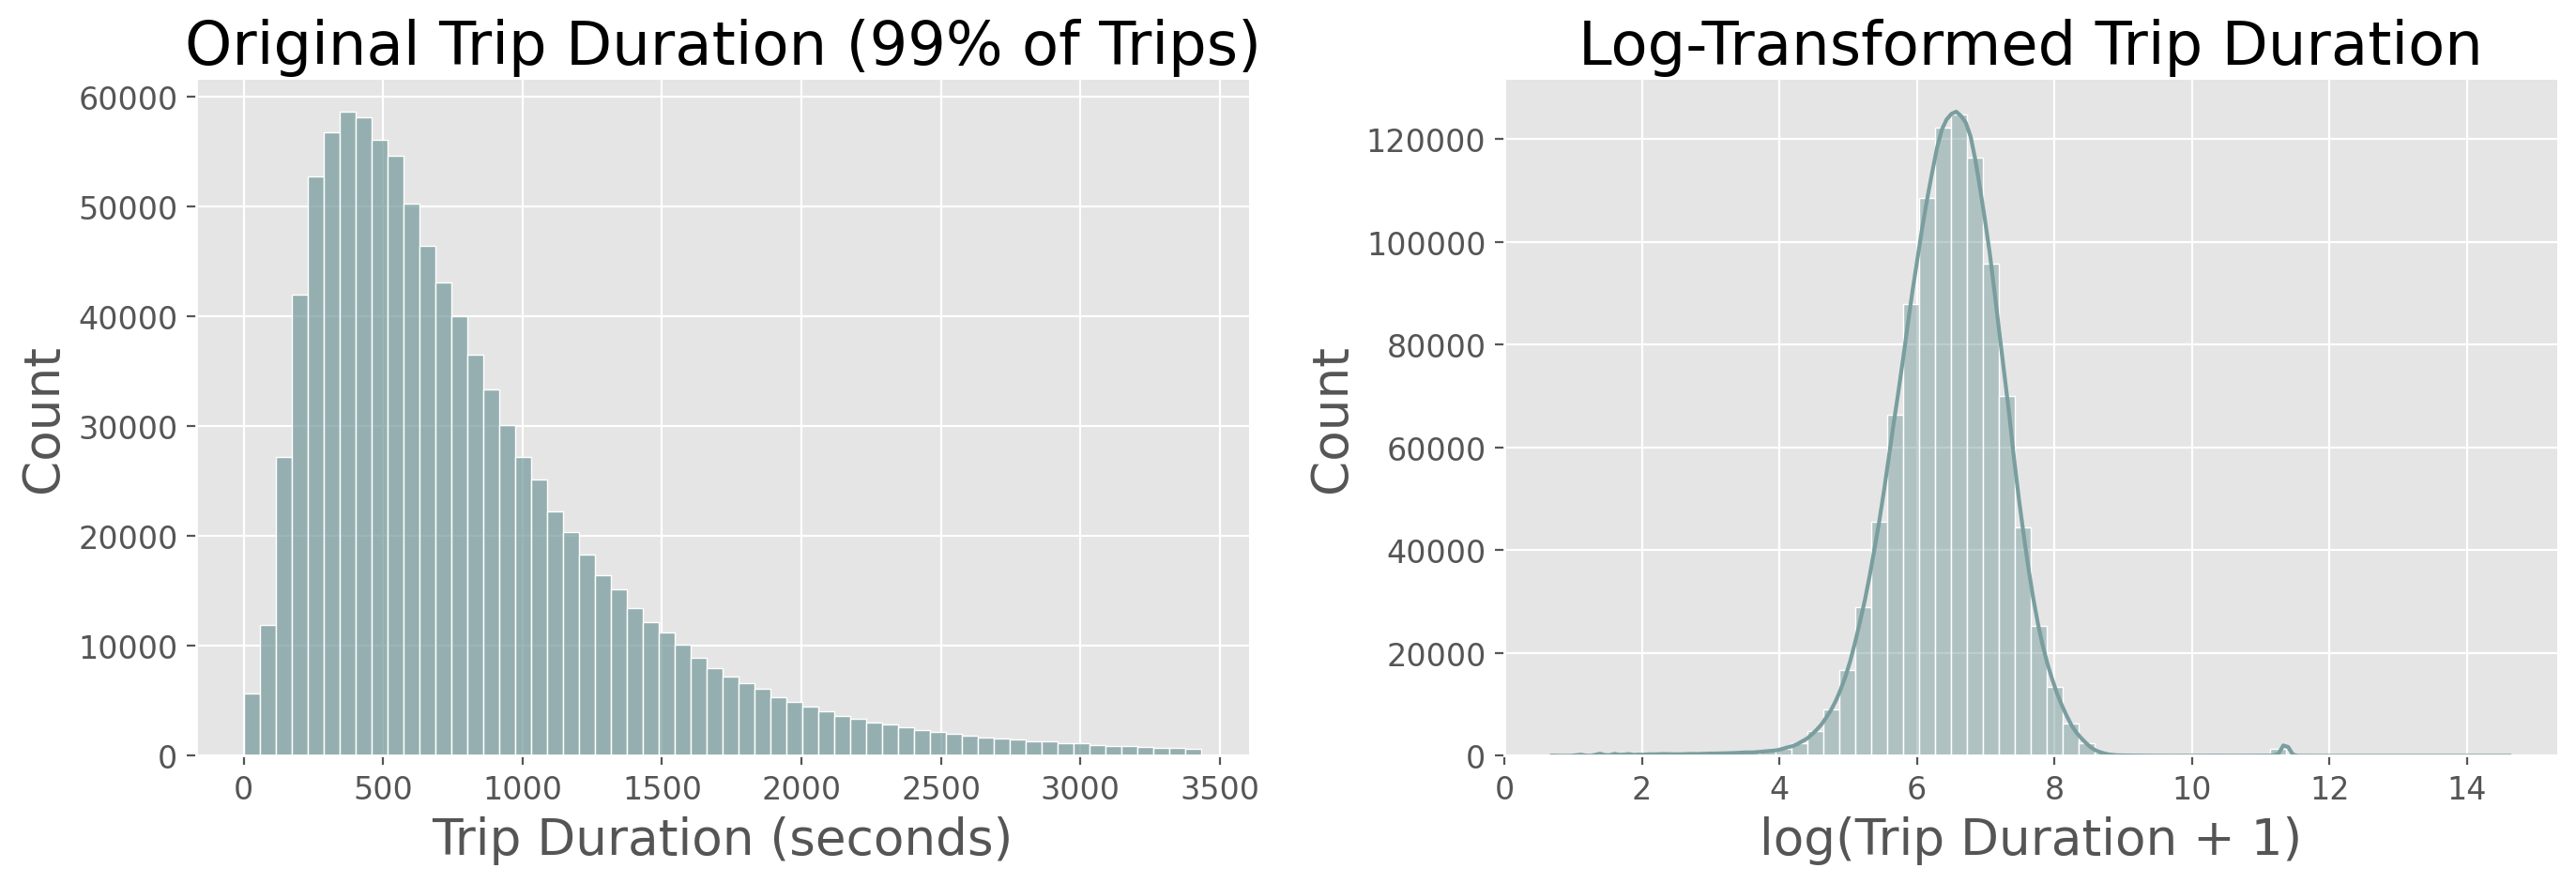

In [70]:
upper = df['trip_duration'].quantile(0.99)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Original
_=sns.histplot(
    df[df['trip_duration'] <= upper]['trip_duration'],
    bins=60,
    color='#7A9E9F',
    edgecolor='white',
    ax=ax[0]
)

_=ax[0].set(
    title='Original Trip Duration (99% of Trips)',
    xlabel='Trip Duration (seconds)',
    ylabel='Count'
)

# Log
_=sns.histplot(
    np.log1p(df['trip_duration']),
    bins=60,
    kde=True,
    color='#7A9E9F',
    edgecolor='white',
    ax=ax[1]
)

_=ax[1].set(
    title='Log-Transformed Trip Duration',
    xlabel='log(Trip Duration + 1)',
    ylabel='Count'
)

plt.tight_layout()
plt.show()

The original trip_duration is right skewed, later to be log transformed.

# 4. Bivariate Exploration

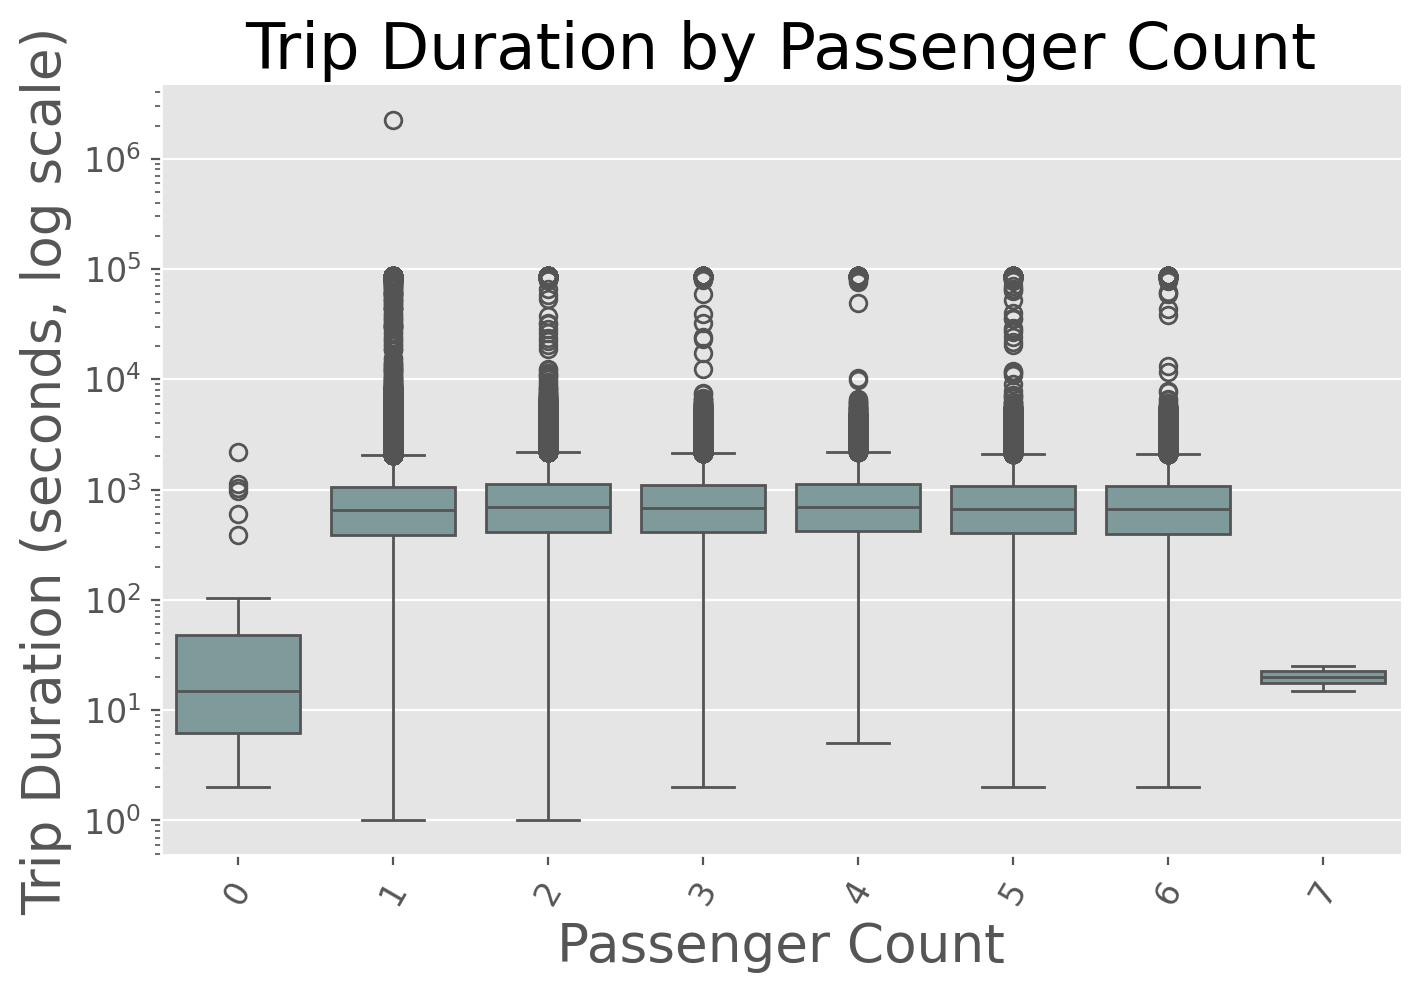

In [88]:
fig, ax = plt.subplots(figsize=(8, 5))

_=sns.boxplot(
    x='passenger_count',
    y='trip_duration',
    data=df,
    color='#7A9E9F',
    ax=ax
)

_=ax.set_yscale('log')

_=ax.set(
    title='Trip Duration by Passenger Count',
    xlabel='Passenger Count',
    ylabel='Trip Duration (seconds, log scale)'
)

_=ax.tick_params(axis='x', labelrotation=60)

plt.show()

Passenger count in range **[1-6]** have almost the same median of trip duration. 

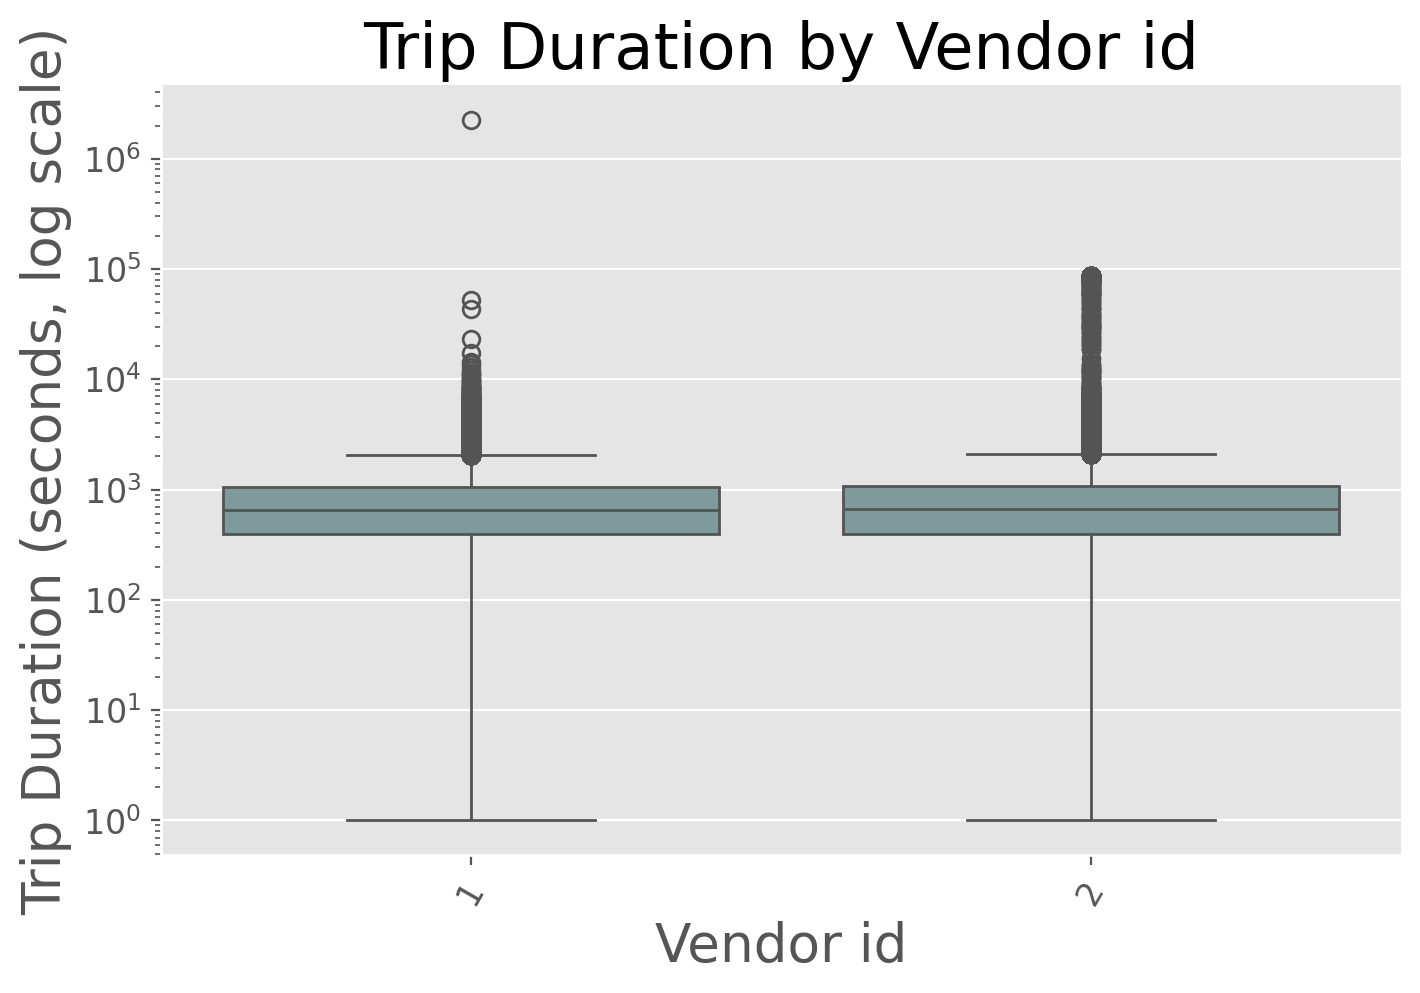

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))

_=sns.boxplot(
    x='vendor_id',
    y='trip_duration',
    data=df,
    color='#7A9E9F',
    ax=ax
)

_=ax.set_yscale('log')

_=ax.set(
    title='Trip Duration by Vendor id',
    xlabel='Vendor id',
    ylabel='Trip Duration (seconds, log scale)'
)

_=ax.tick_params(axis='x', labelrotation=60)

plt.show()

Both vendor id of 1 and 2 have the same median of trip duration, however vendor with id=2 have the most trips in the data, that says vendor with id=1 trips much longer than with id=2.

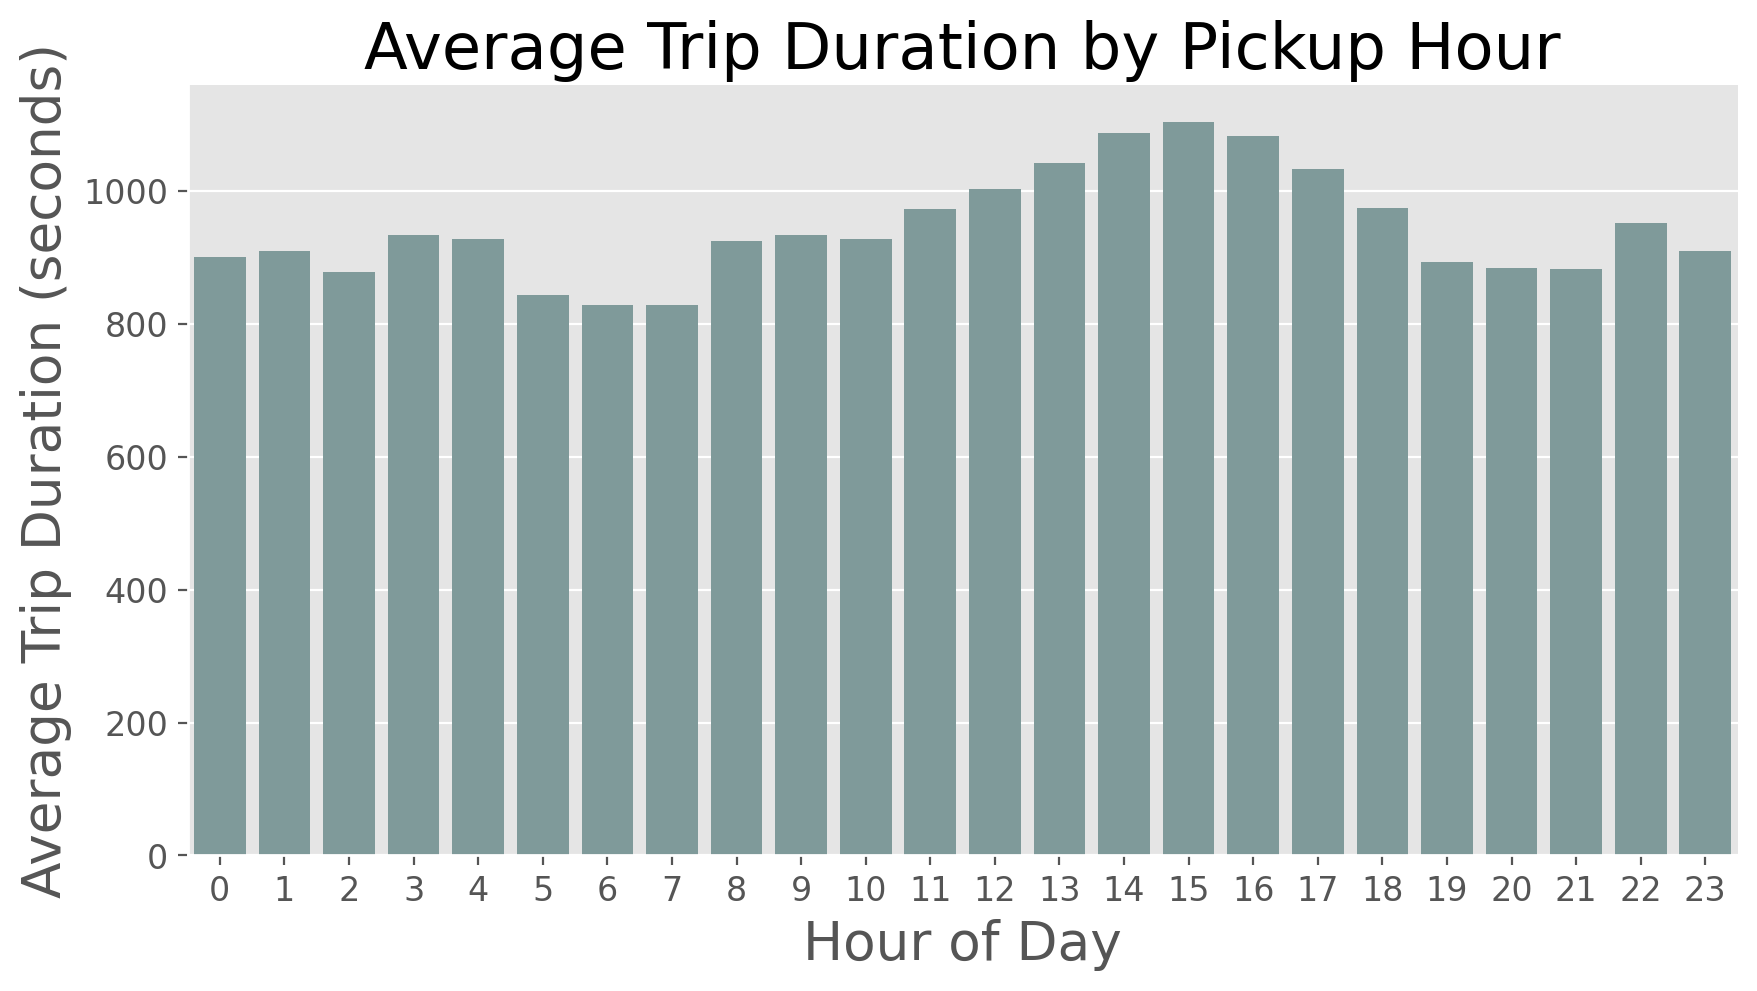

In [94]:
fig, ax = plt.subplots(figsize=(10, 5))

_=sns.barplot(
    data=df,
    x=df['pickup_datetime'].dt.hour,
    y='trip_duration',
    color='#7A9E9F',
    estimator='mean',
    errorbar=None,
    ax=ax
)

_=ax.set(
    title='Average Trip Duration by Pickup Hour',
    xlabel='Hour of Day',
    ylabel='Average Trip Duration (seconds)'
)

plt.show()

Looks like hours of day in range **[12-17]** are rush hours.

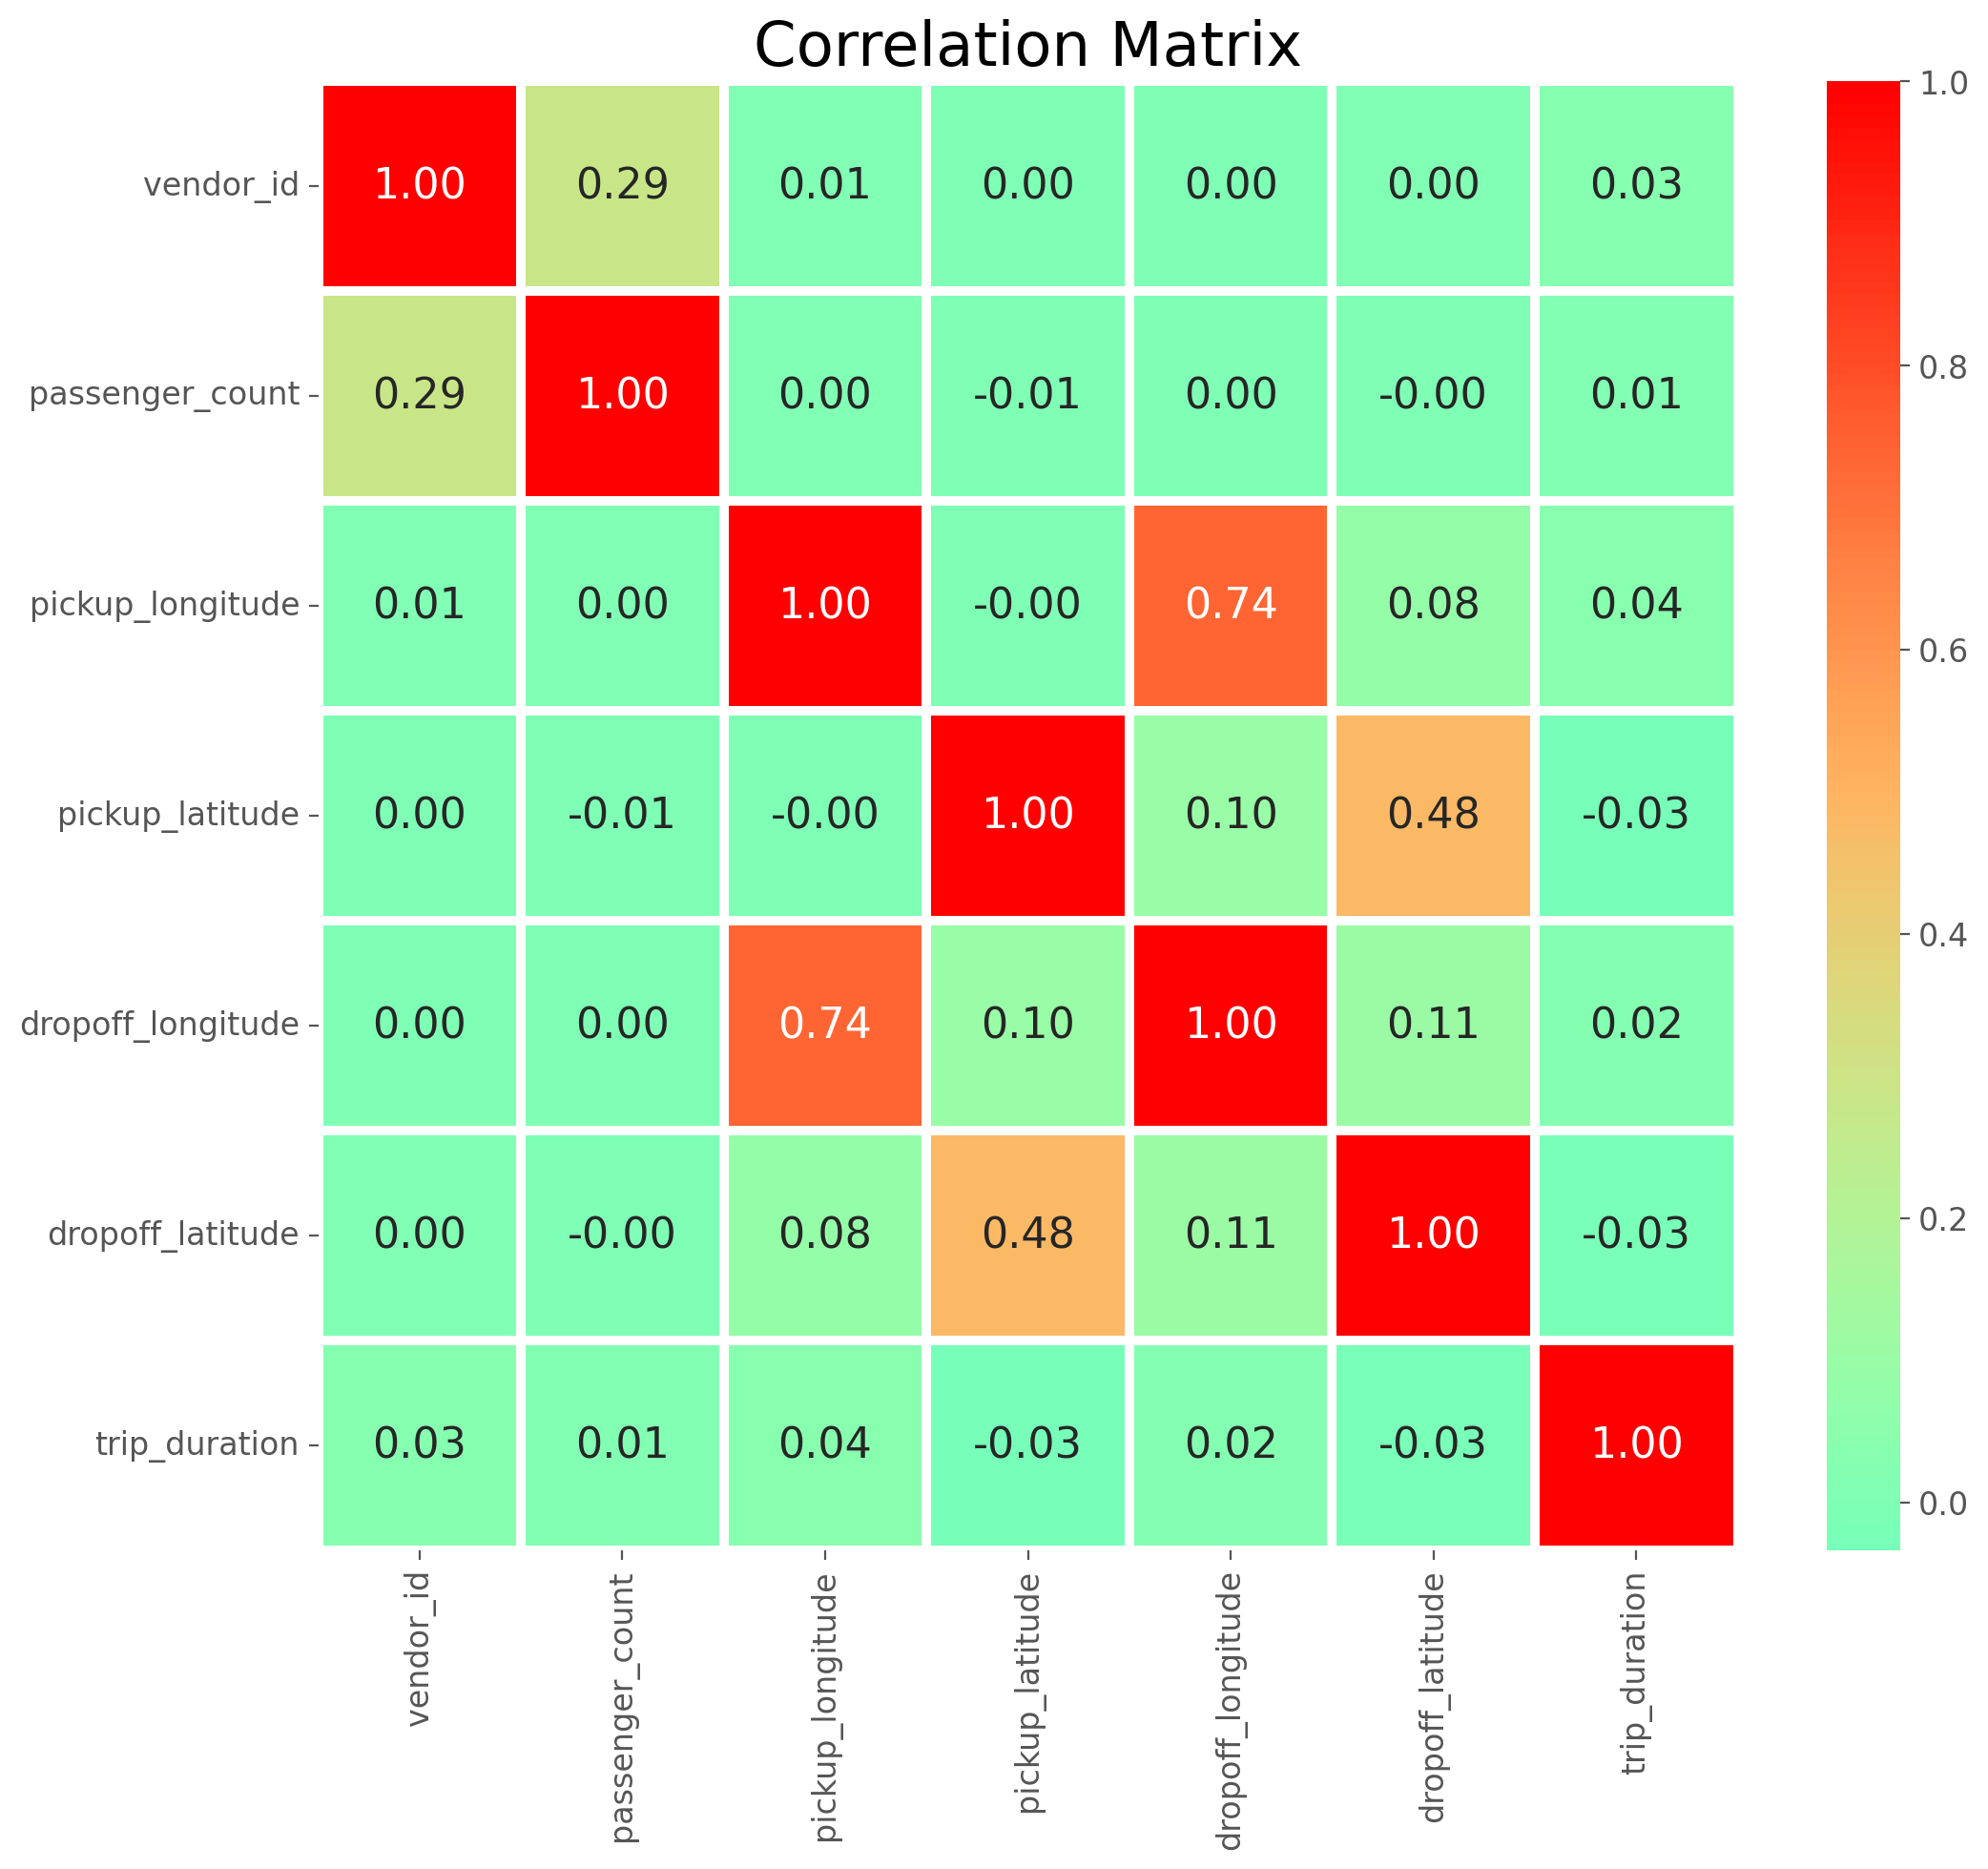

In [92]:
# Correlation matrix using only numeric columns
corr = df.select_dtypes(include='number').corr()

fig, ax = plt.subplots(figsize=(12, 10))

_=sns.heatmap(
    corr,
    annot=True,
    linewidths=3,
    center=0,
    cmap='rainbow',
    fmt='.2f',
    ax=ax
)

_=ax.set_title('Correlation Matrix')

plt.show()

* As shown, most relations are linearly weak.
* We will need more feature to be added.

# 5. Multivariate Exploration

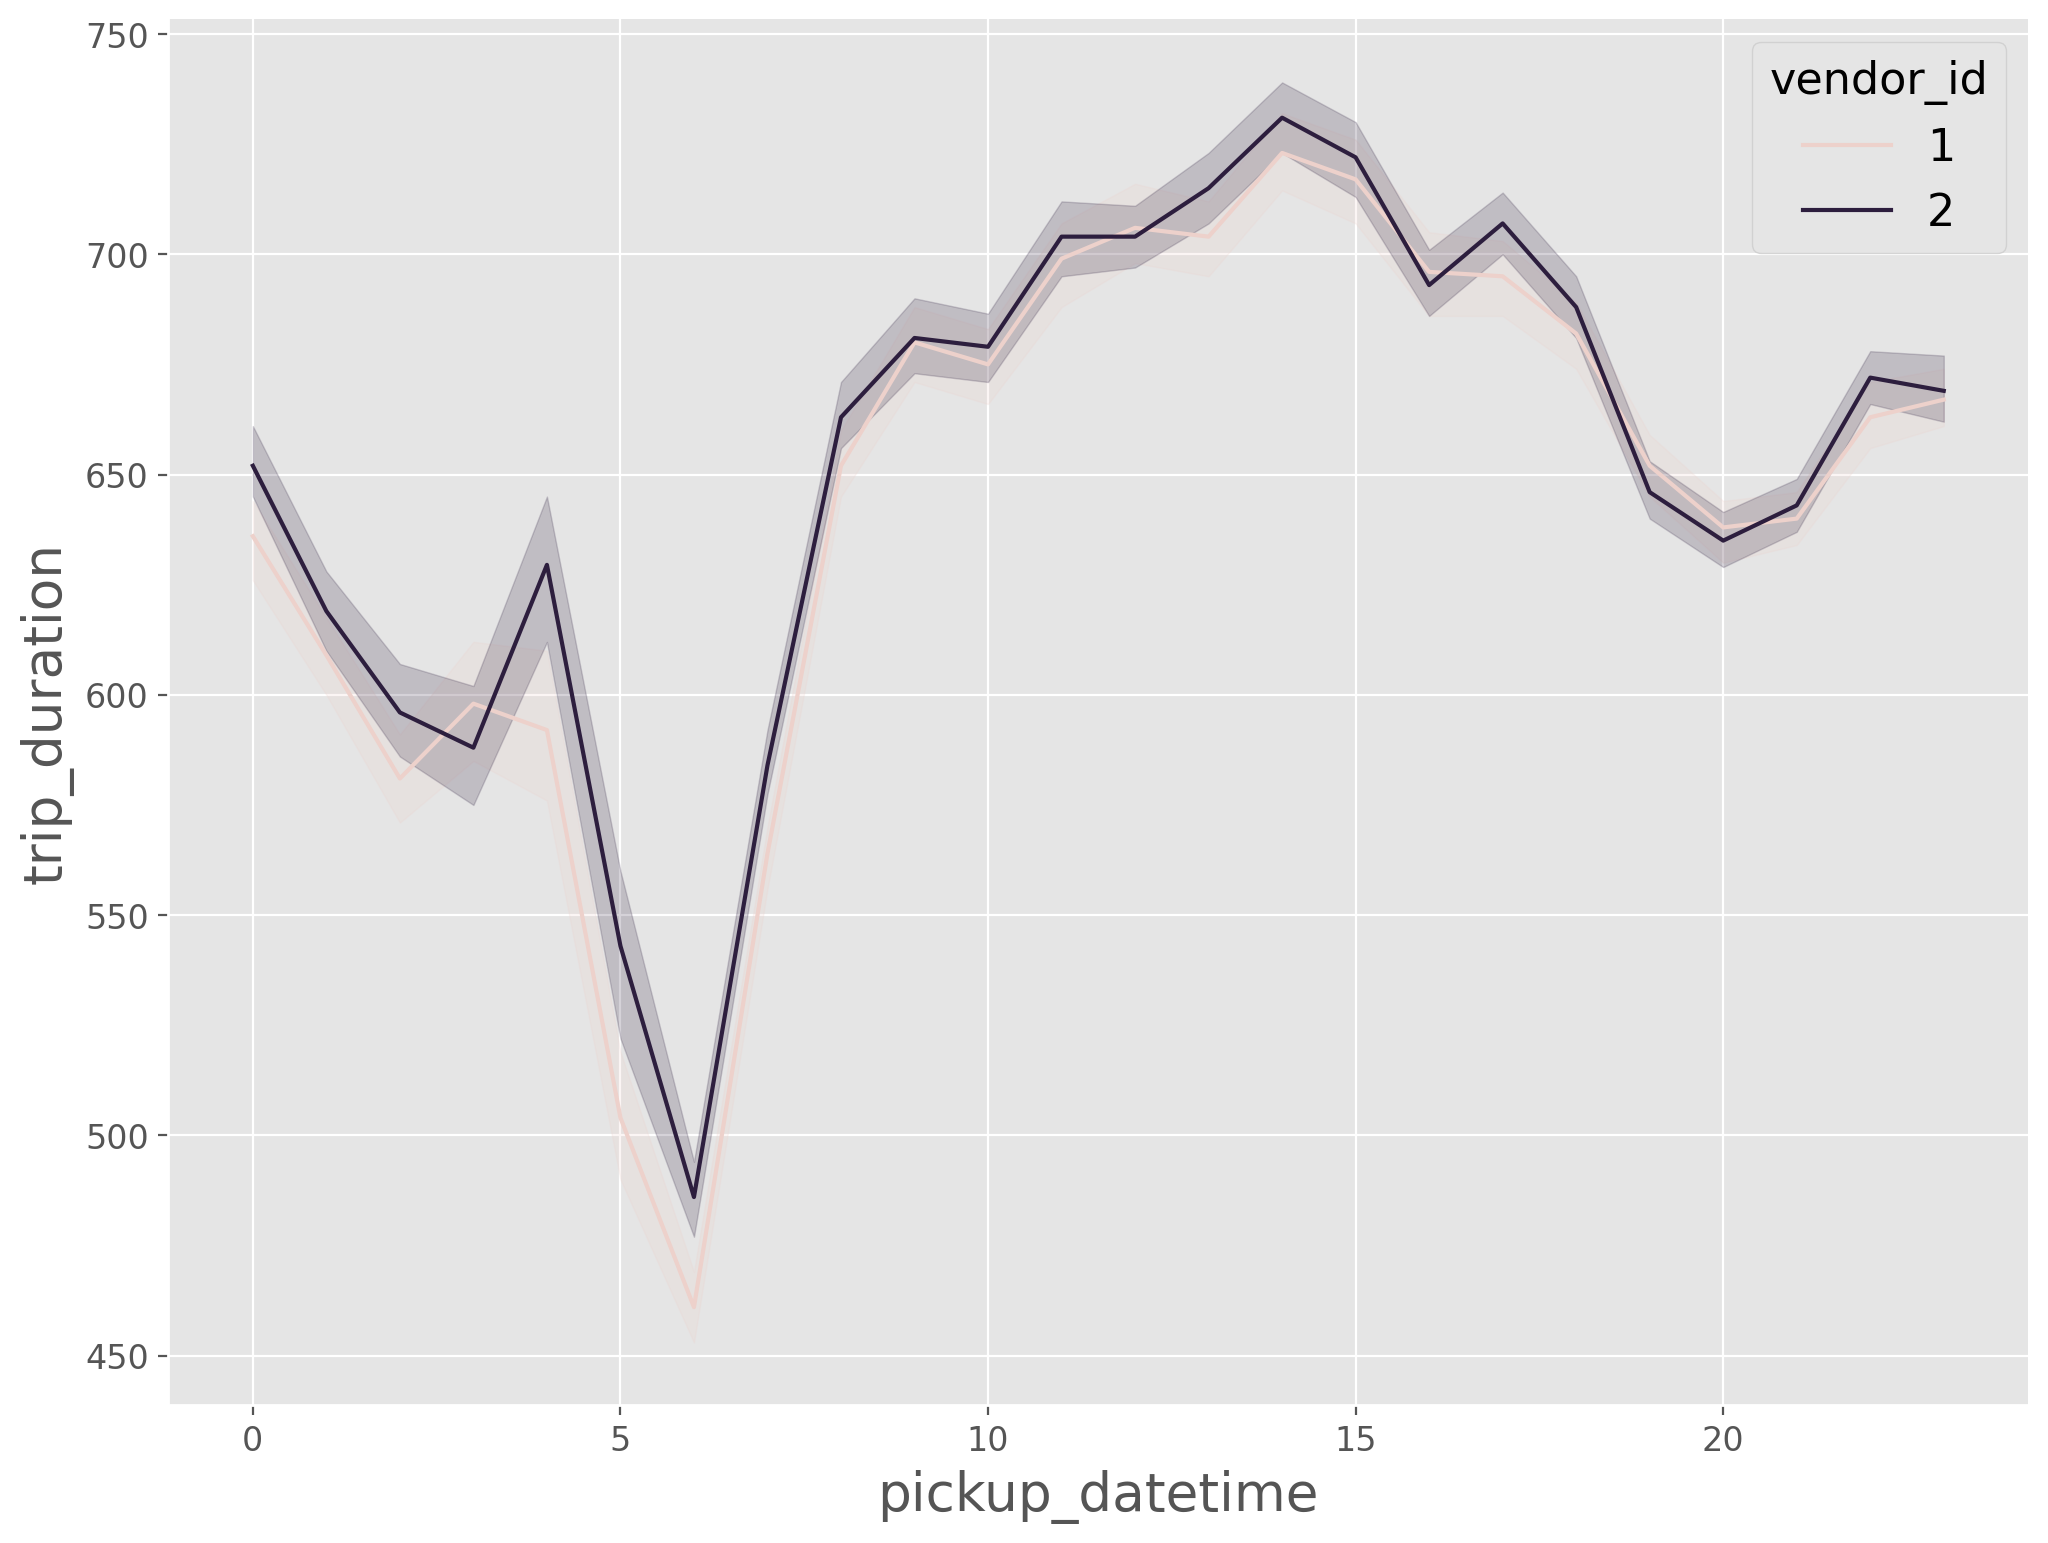

In [101]:
_=sns.lineplot(
    data=df,
    x=df['pickup_datetime'].dt.hour,
    y='trip_duration',
    hue='vendor_id',
    estimator='median'
)

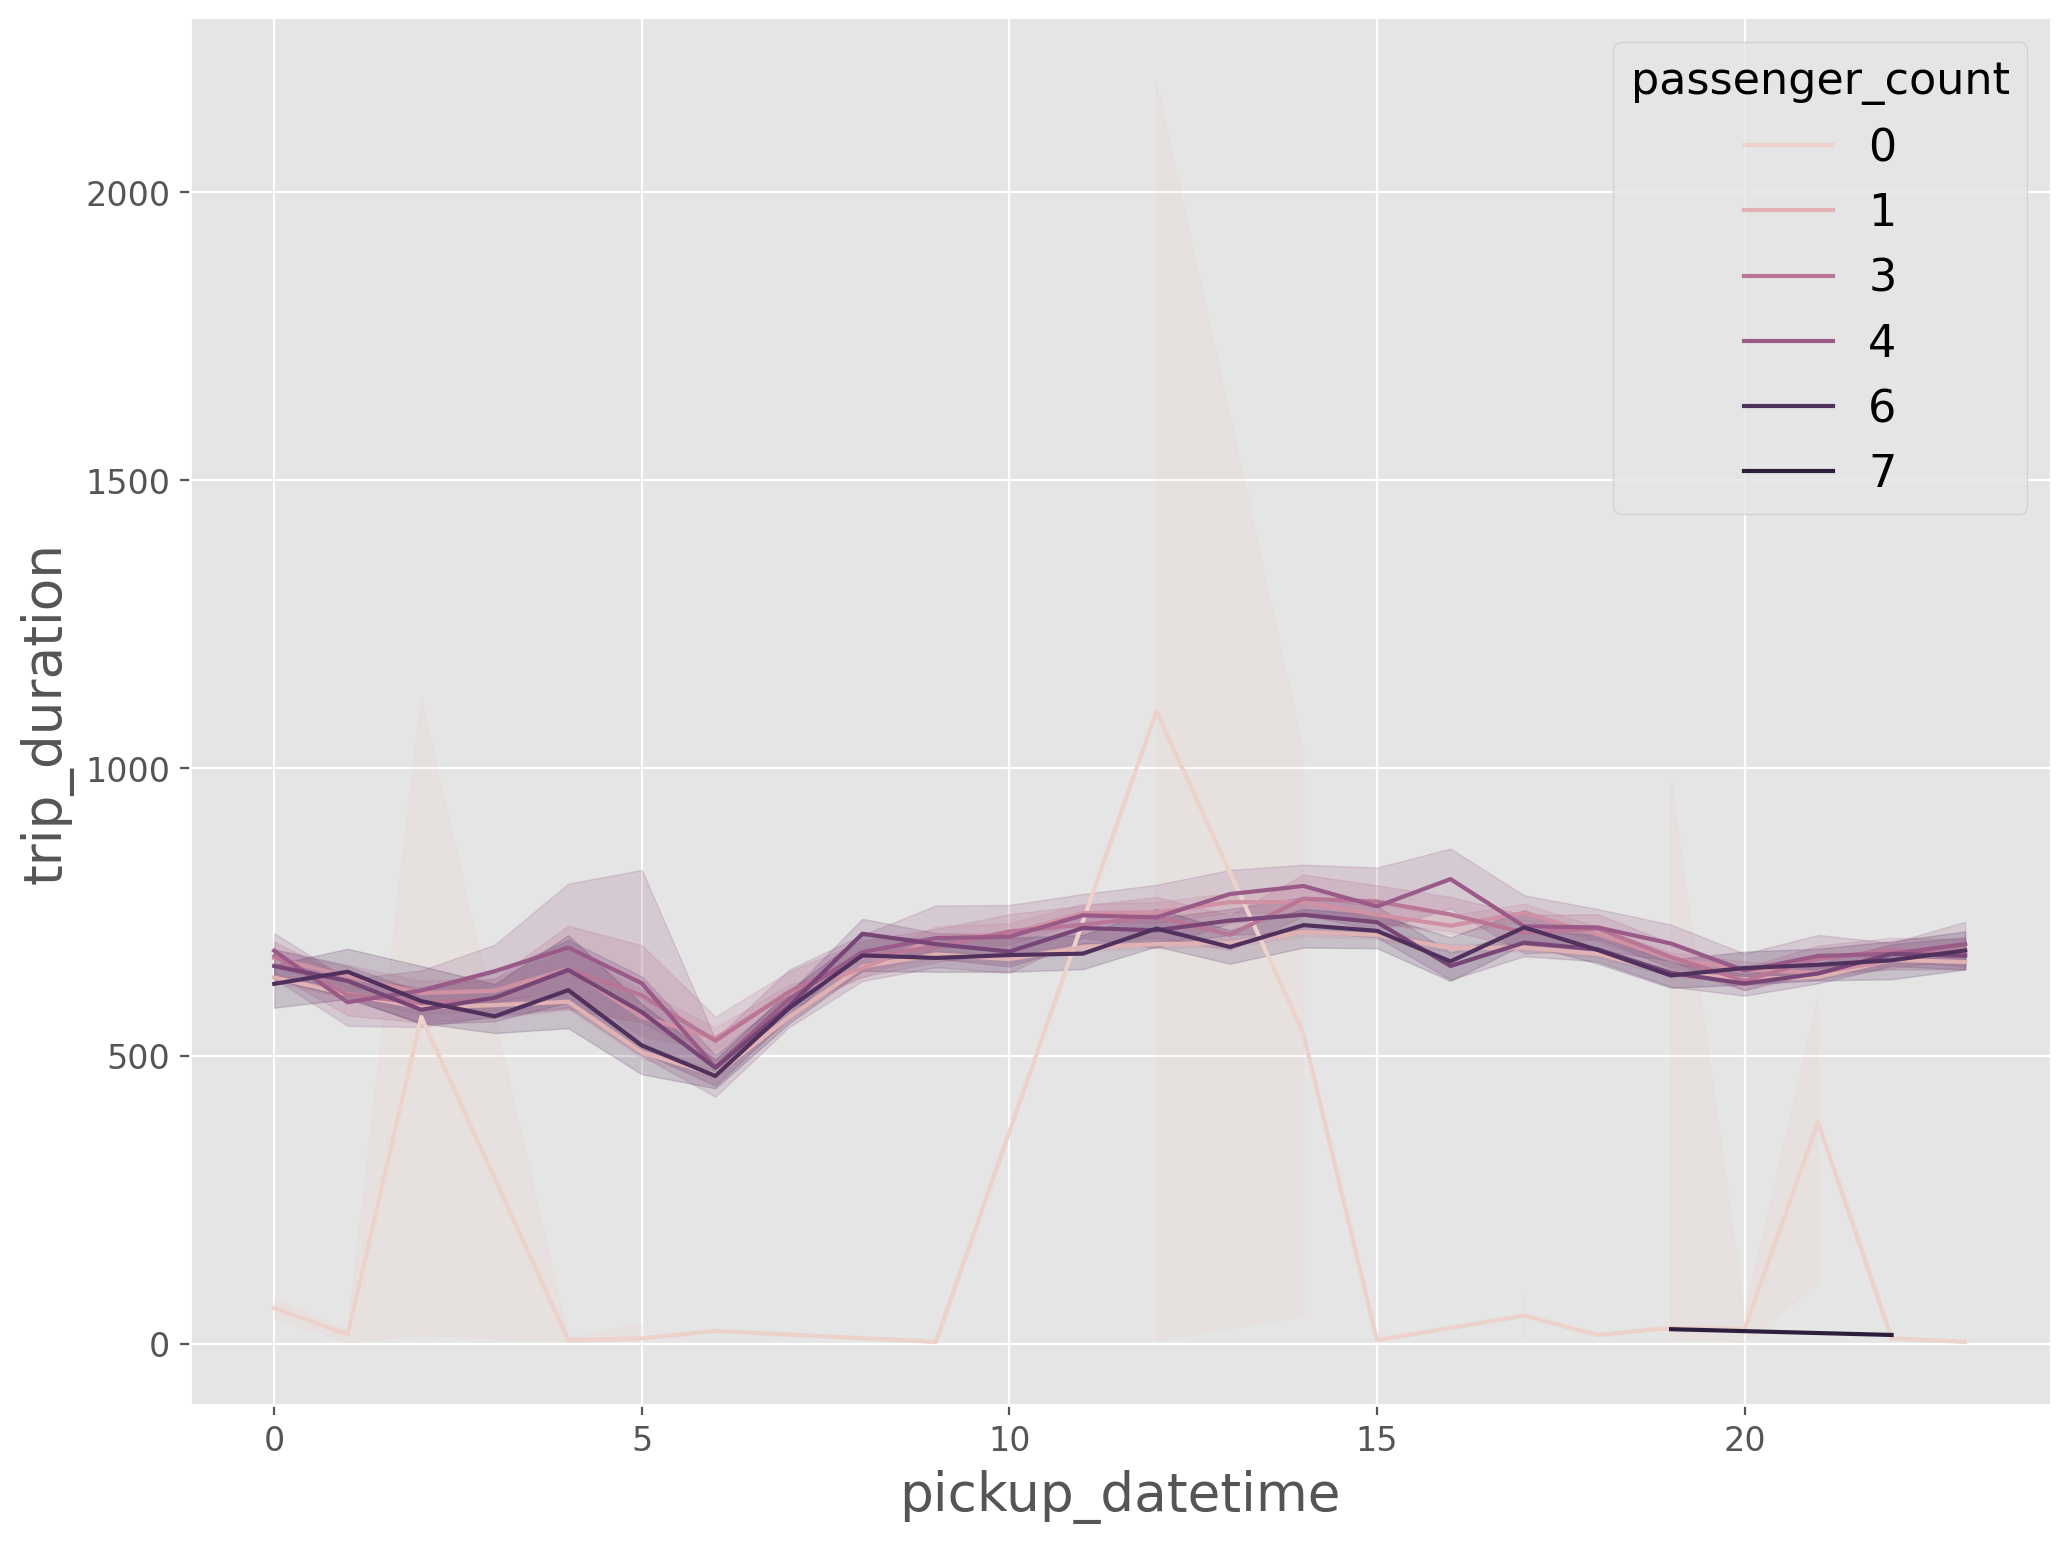

In [102]:
_=sns.lineplot(
    data=df,
    x=df['pickup_datetime'].dt.hour,
    y='trip_duration',
    hue='passenger_count',
    estimator='median'
)

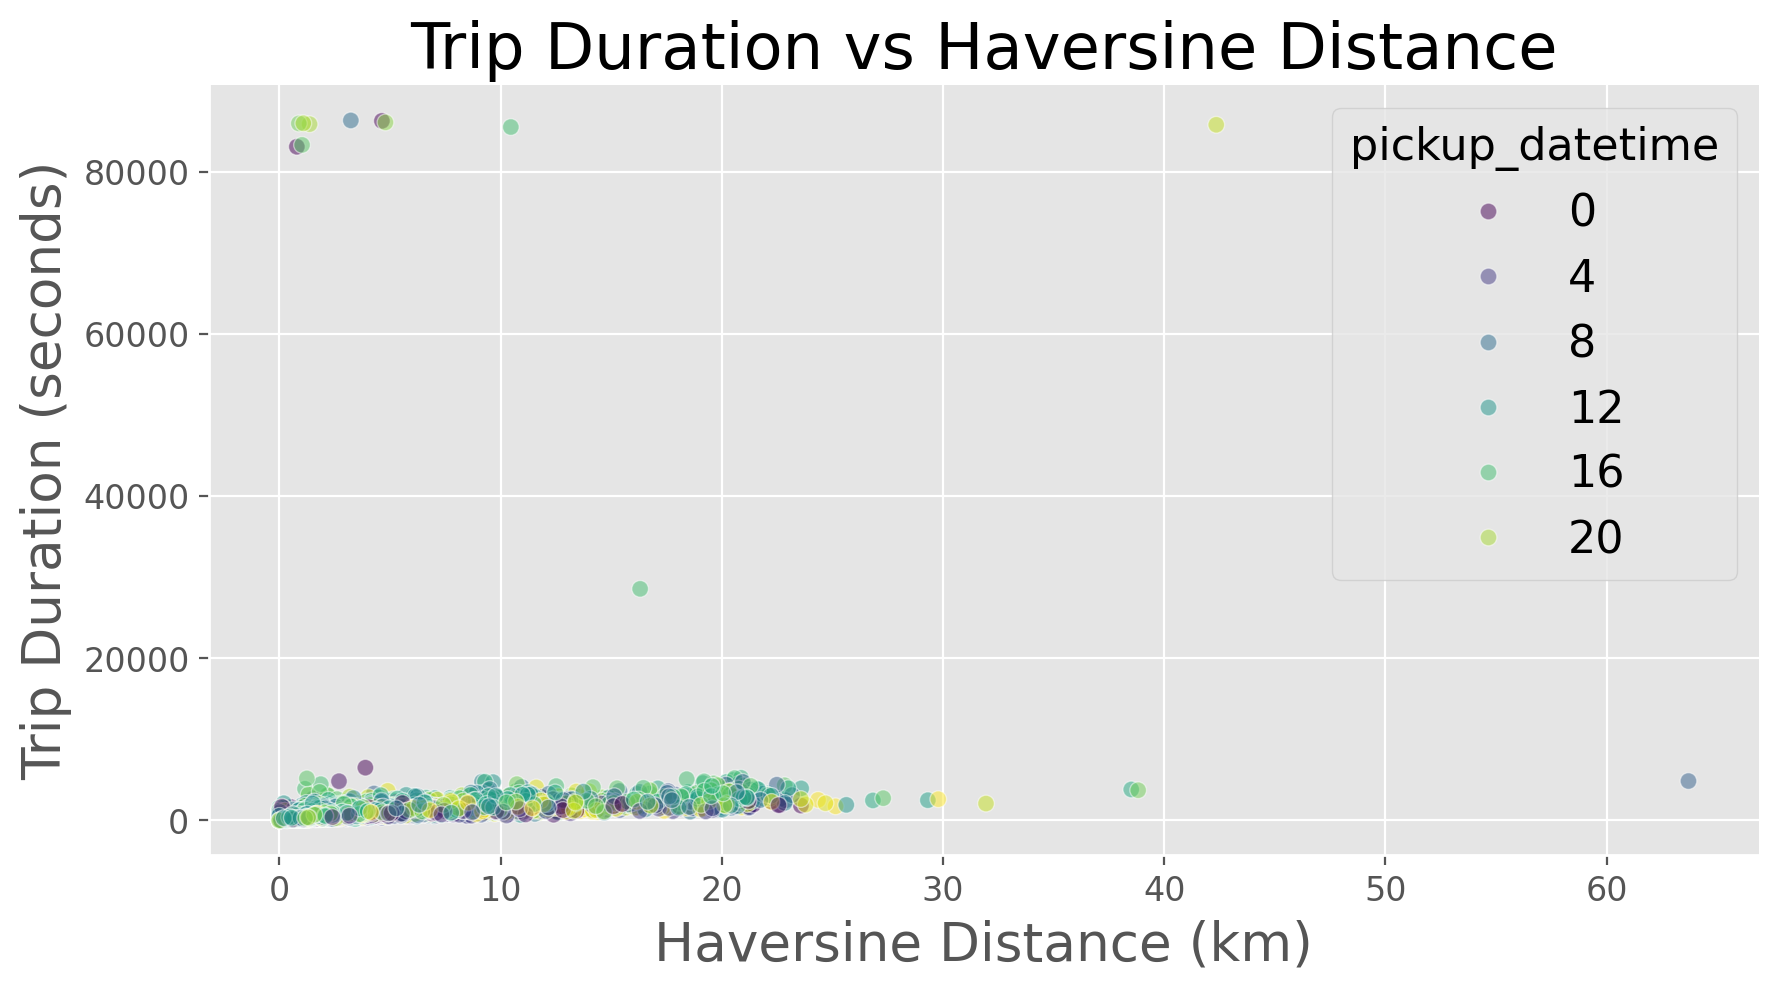

In [107]:
sample = df.sample(10000, random_state=42)

R = 6371  # Earth's radius in km

lat1 = np.radians(sample['pickup_latitude'])
lon1 = np.radians(sample['pickup_longitude'])
lat2 = np.radians(sample['dropoff_latitude'])
lon2 = np.radians(sample['dropoff_longitude'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
c = 2 * np.arcsin(np.sqrt(a))

distance = R * c


fig, ax = plt.subplots(figsize=(10, 5))

_=sns.scatterplot(
    x=distance,
    y=sample['trip_duration'],
    hue=sample['pickup_datetime'].dt.hour,
    alpha=0.5,
    palette='viridis',
    ax=ax
)

_=ax.set(
    title='Trip Duration vs Haversine Distance',
    xlabel='Haversine Distance (km)',
    ylabel='Trip Duration (seconds)'
)

plt.show()

Insights:

* Trip duration generally increases as Haversine distance increases, indicating a positive correlation between travel distance and travel time.
* Considerable variability exists for trips of similar distances, highlighting the influence of additional factors such as traffic conditions and route selection.
* Most trips are relatively short (less than 20 km) with durations under 4,000 seconds.
* A small number of extreme observations suggest the presence of outliers or anomalous trips that should be examined during data preprocessing.

# 6. Brief Conclusion of the EDA

The EDA shows that trip duration is highly right-skewed and influenced by both temporal and spatial factors. Distance exhibits a positive relationship with trip duration, while pickup time and location also contribute to its variability. Based on these findings, feature engineering will focus on extracting temporal features, computing geographic distance metrics, generating spatial clusters, encoding categorical variables, and scaling numerical features to improve model performance.